# Appendix B. The source code.

## Load the data

In [1]:
import pandas

full_data = pandas.read_csv("bda_data.csv", index_col = "Unnamed: 0")
full_data.nunique()

VendorID                   3
passenger_count            5
trip_distance            711
PULocationID              84
DOLocationID             147
payment_type               4
fare_amount              229
extra                     15
mta_tax                    2
tip_amount               485
tolls_amount             384
improvement_surcharge      2
total_amount             856
congestion_surcharge       2
Airport_fee                4
cbd_congestion_fee         2
dtype: int64

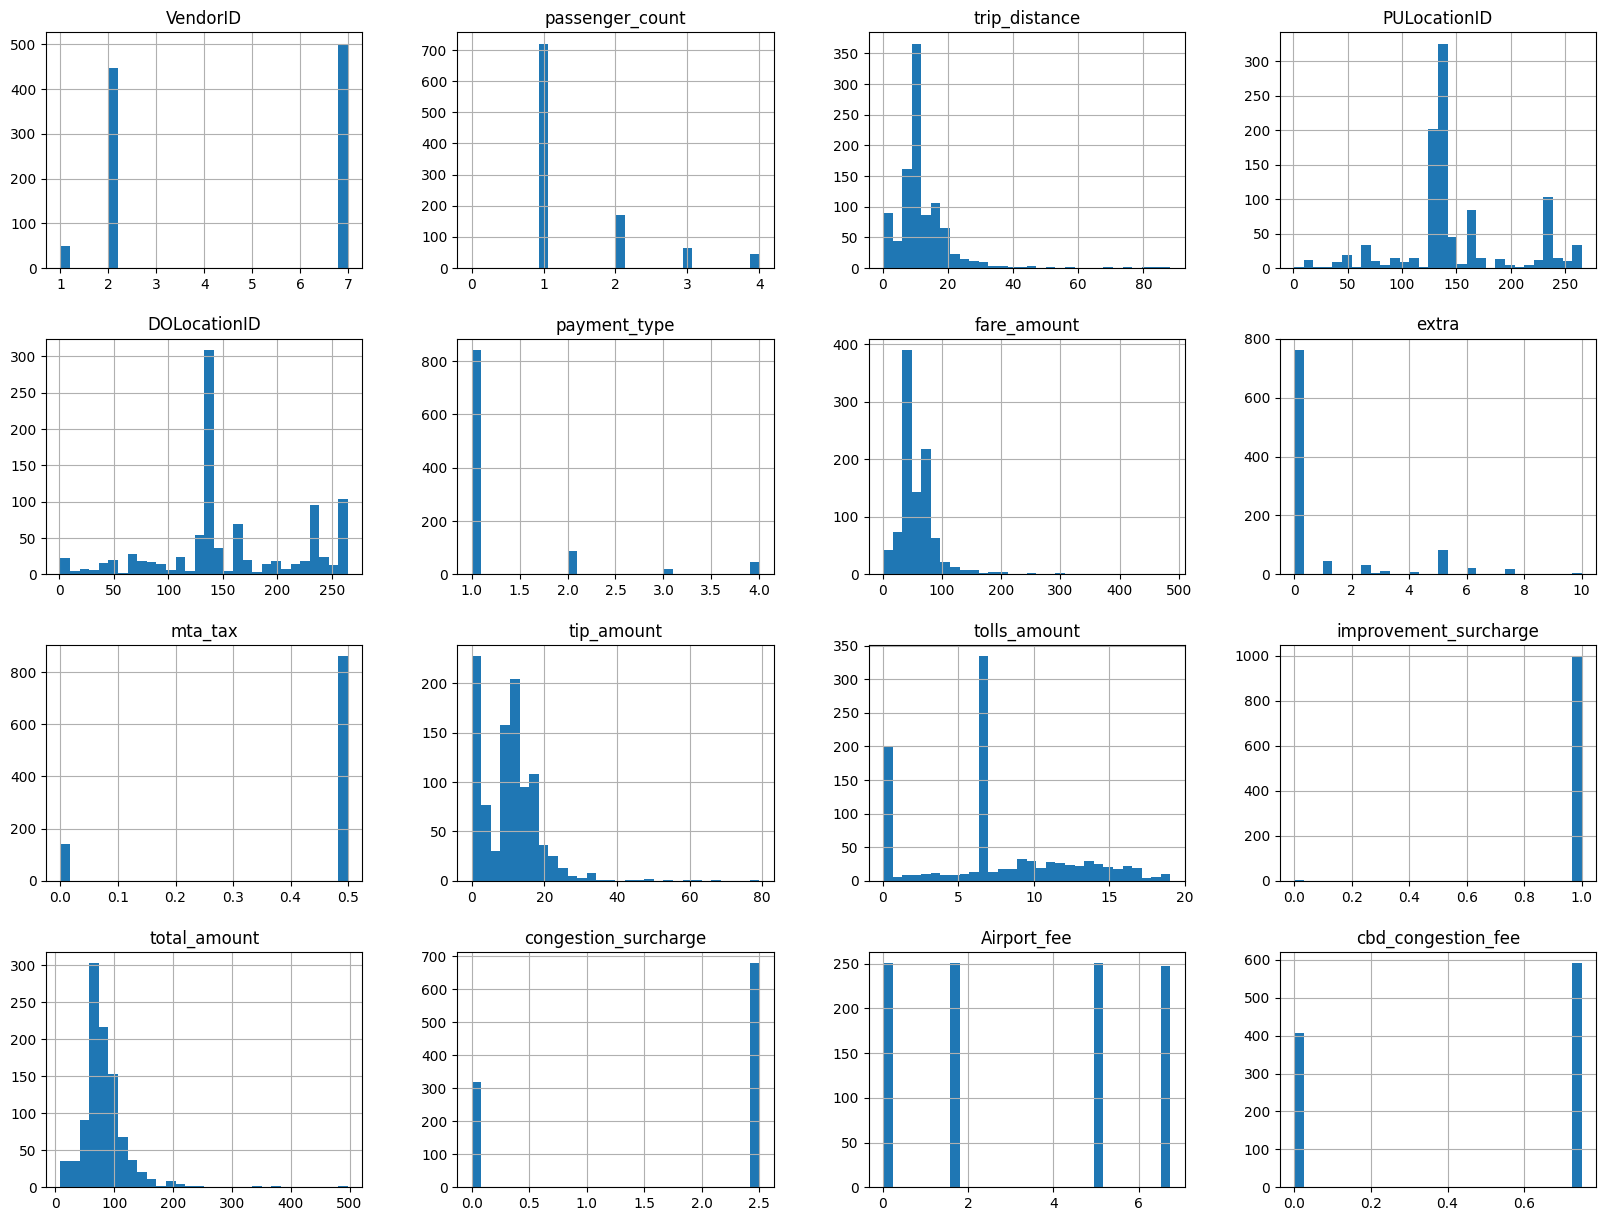

In [2]:
full_data.hist(figsize = (20, 15), bins = 30)
None

## Homework Assignment 1: Correlation Coefficient

### Task 1
Find two features in your dataset with more or less “linear-like” scatterplot.

Let's drop non-quantitive features for ease of analysis. Categorical and ordinal features are not interesting in this work.

In [3]:
data = full_data[["trip_distance", "fare_amount", "tip_amount", "tolls_amount", "total_amount"]]
data

,trip_distance,fare_amount,tip_amount,tolls_amount,total_amount
0,1.89,14.2,3.99,0.00,23.94
1,4.70,22.6,6.80,0.01,34.16
2,15.18,86.0,17.42,0.12,104.54
3,15.90,61.1,25.00,0.16,91.01
4,0.00,3.0,0.00,0.20,8.95
...,...,...,...,...,...
995,8.97,40.1,14.63,6.94,73.17
996,8.81,42.2,12.13,6.94,72.77
997,14.77,64.6,16.61,6.94,99.65
998,9.07,44.3,12.55,6.94,75.29


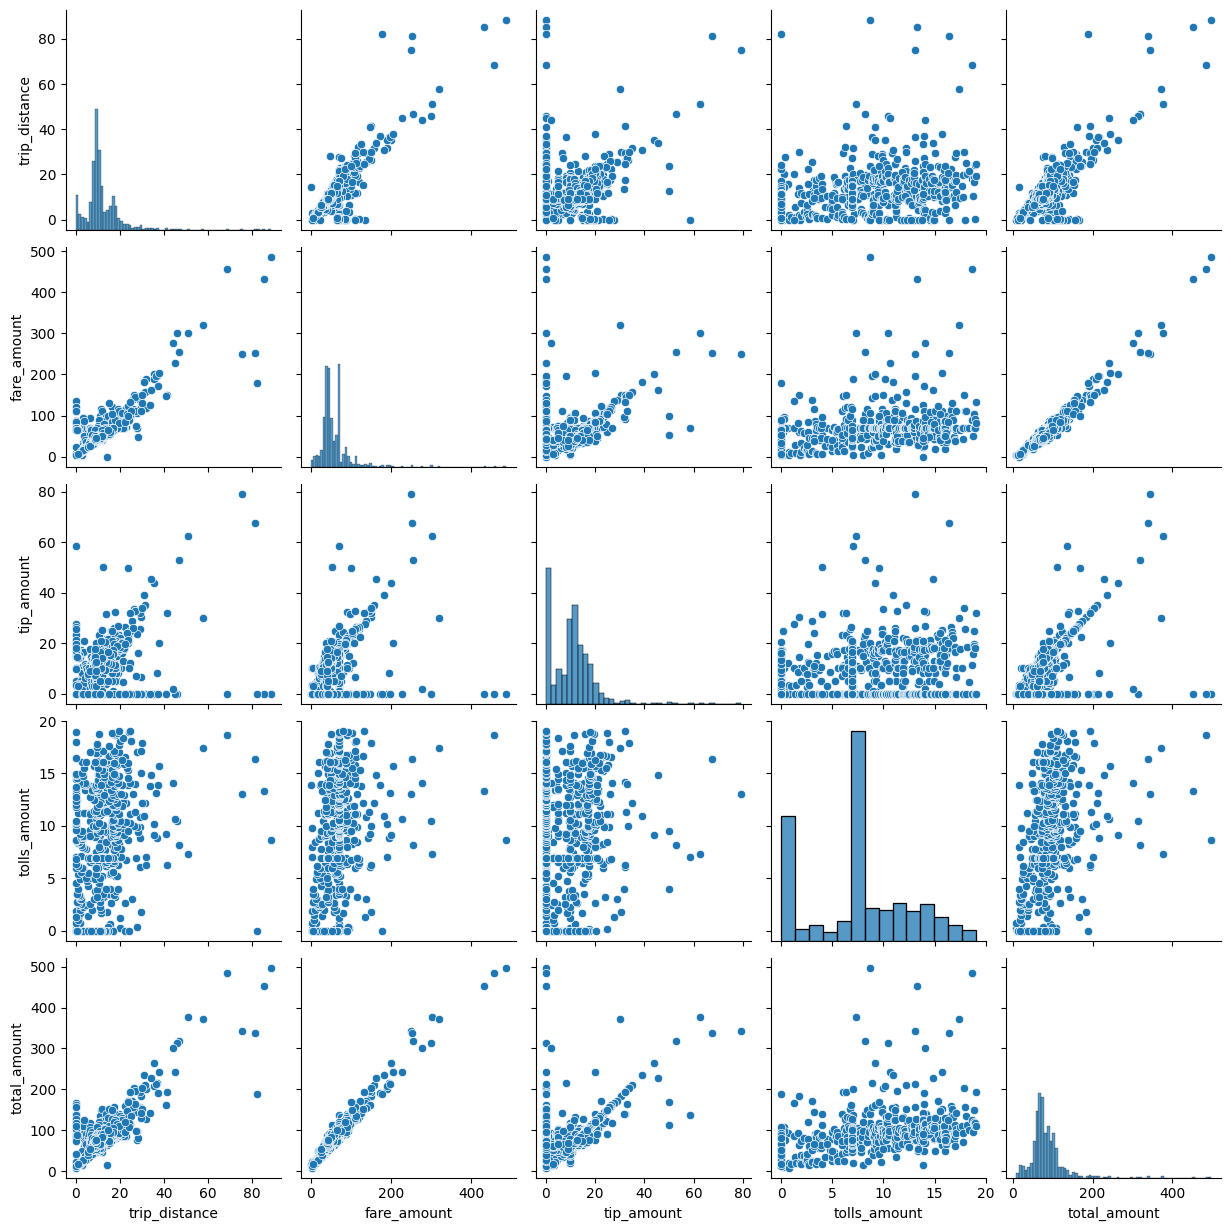

In [4]:
import seaborn
seaborn.pairplot(data)

### Task 2
Display the scatter-plot and comment how well it is suitable for building a linear regression.

Text(0, 0.5, 'total_amount')

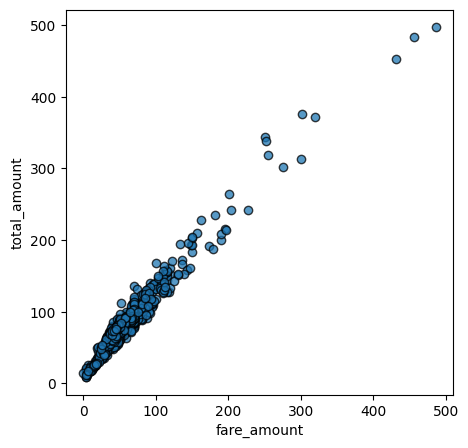

In [5]:
import matplotlib.pyplot as plt

x = data[["fare_amount"]].to_numpy().flatten()
y = data[["total_amount"]].to_numpy().flatten()

plt.figure(figsize = (5, 5))
plt.scatter(x, y, alpha = 0.75, edgecolors = 'black')
plt.xlabel("fare_amount")
plt.ylabel("total_amount")

### Task 3
Build a linear regression of one of the features over the other. Make a comment on the meaning of the slope.

In [6]:
x_cen = x - x.mean()
y_cen = y - y.mean()

k = (y_cen @ x_cen) / (x_cen @ x_cen)
b = y.mean() - k * x.mean()
k, b

(1.0833981108784132, 20.991688669102025)

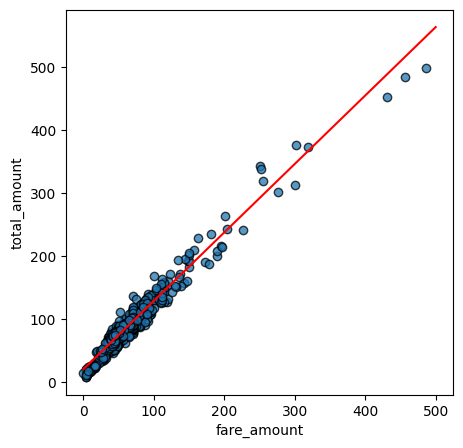

In [7]:
import numpy

plt.figure(figsize = (5, 5))
plt.scatter(x, y, alpha = 0.75, edgecolors = 'black')
plt.xlabel("fare_amount")
plt.ylabel("total_amount")

plot_x = numpy.linspace(0, 500)
plt.plot(plot_x, k * plot_x + b, color = 'red')

### Task 4
Find the correlation and determinacy coefficients, and comment on the meaning of the latter.

In [8]:
corr = (y_cen @ x_cen) / (len(x) * numpy.std(x) * numpy.std(y))
corr

0.9762789402934781

In [9]:
deter = corr ** 2
deter

0.9531205692605565

### Task 5
Make a prediction of the target values for given three or four predictor’ values; make a comment.

In [10]:
report = []
for idx in [ 232, 872, 209, 28 ]:
    y_pred = k * x[idx] + b
    error = numpy.abs(y[idx] - y_pred)
    report.append({
        'Fare amount': x[idx],
        'True total amount': y[idx],
        'Predicted total amount': y_pred,
        'Absolute error': error,
        'Relative absolute error (DA)': 100 * error / numpy.abs(y[idx]),
        'Relative absolute error (ML)': 100 * error / numpy.abs(y_pred)
    })
pandas.DataFrame(report)

,Fare amount,True total amount,Predicted total amount,Absolute error,Relative absolute error (DA),Relative absolute error (ML)
0,95.0,127.77,123.914509,3.855491,3.017524,3.111412
1,52.7,80.25,78.086769,2.163231,2.695615,2.770291
2,70.2,87.70,97.046236,9.346236,10.657054,9.630704
3,136.7,172.50,169.092210,3.407790,1.975530,2.015344


The predictions differ from the true values. However, the difference is not that big considering the scale of the values.

### Task 6
Compare the mean relative absolute error of the regression on all points of your set according to DA and ML views

In [11]:
y_pred = k * x + b
y_pred.shape, y.shape

((1000,), (1000,))

In [12]:
da_error = 100 * numpy.abs(y - y_pred) / numpy.abs(y)
ml_error = 100 * numpy.abs(y - y_pred) / numpy.abs(y_pred)

da_error.mean(), ml_error.mean()

(11.318835308355892, 9.85888256763886)

## Homework Assignment 2: PCA/SVD

### Task 1
In your data set, select a subset of 3-6 features related to the same aspect and explain your choice

In [13]:
data = full_data[["trip_distance", "fare_amount", "tip_amount", "tolls_amount", "total_amount"]]
data

,trip_distance,fare_amount,tip_amount,tolls_amount,total_amount
0,1.89,14.2,3.99,0.00,23.94
1,4.70,22.6,6.80,0.01,34.16
2,15.18,86.0,17.42,0.12,104.54
3,15.90,61.1,25.00,0.16,91.01
4,0.00,3.0,0.00,0.20,8.95
...,...,...,...,...,...
995,8.97,40.1,14.63,6.94,73.17
996,8.81,42.2,12.13,6.94,72.77
997,14.77,64.6,16.61,6.94,99.65
998,9.07,44.3,12.55,6.94,75.29


In [14]:
data_npy = data.to_numpy()
data_npy.shape

(1000, 5)

### Task 2
Standardize the selected subset; compute its data scatter and SVD; determine contributions of all the principal components to the data scatter, naturally and per cent

In [15]:
data_mean = data_npy.mean(axis = 0)
data_std = data_npy.std(axis = 0)
data_max = data_npy.max(axis = 0)
data_min = data_npy.min(axis = 0)

data_zscore = (data_npy - data_mean) / data_std
data_range = (data_npy - data_mean) / (data_max - data_min)
data_rank = (data_npy - data_min) / (data_max - data_min)

data_npy.shape, data_zscore.shape, data_range.shape, data_rank.shape

((1000, 5), (1000, 5), (1000, 5), (1000, 5))

In [16]:
data_mean

array([11.93162, 58.51561, 10.4085 ,  7.38076, 84.38739])

In [17]:
data_std

array([ 8.75146646, 40.30436962,  8.52870567,  5.04001518, 44.72664124])

In [18]:
data_max

array([ 88.35, 486.  ,  79.21,  19.06, 497.44])

In [19]:
data_min

array([0.  , 0.01, 0.  , 0.  , 8.51])

In [20]:
def SVD(data: numpy.ndarray):
    numpy.set_printoptions(suppress = True)
    scatter = (data * data).sum()
    print('Data scatter: ', numpy.round(scatter, 2))

    U, S, V = numpy.linalg.svd(data, full_matrices = True)
    print(U.shape)
    print(numpy.round(S, 2))
    print(numpy.round(V.T, 3))

    print(f'Contributions: ', numpy.round(S ** 2, 2))
    print('Contributions (%): ', numpy.round(100 * (S ** 2) / scatter, 1))
    numpy.set_printoptions(suppress = False)
    return U, S, V

In [21]:
SVD(data_npy)
None

Data scatter:  14650127.64
(1000, 1000)
[3801.71  369.32  178.41  152.17   75.87]
[[-0.116 -0.081  0.023  0.986  0.089]
 [-0.587 -0.648 -0.241 -0.152  0.393]
 [-0.09   0.614 -0.588  0.007  0.519]
 [-0.062  0.176  0.75  -0.067  0.631]
 [-0.793  0.408  0.183 -0.027 -0.412]]
Contributions:  [14452991.     136395.9     31829.84    23154.31     5756.58]
Contributions (%):  [98.7  0.9  0.2  0.2  0. ]


In [22]:
SVD(data_zscore)
None

Data scatter:  5000.0
(1000, 1000)
[56.13 29.32 27.94 14.35  1.58]
[[ 0.494  0.083  0.35  -0.791 -0.014]
 [ 0.533  0.081  0.264  0.469 -0.648]
 [ 0.283 -0.816 -0.469 -0.114 -0.144]
 [ 0.292  0.565 -0.763 -0.094 -0.068]
 [ 0.554 -0.034  0.076  0.363  0.745]]
Contributions:  [3151.1   859.95  780.58  205.87    2.5 ]
Contributions (%):  [63.  17.2 15.6  4.1  0.1]


In [23]:
SVD(data_range)
None

Data scatter:  106.57
(1000, 1000)
[8.66 4.53 3.02 1.35 0.14]
[[ 0.158  0.525 -0.372 -0.749 -0.012]
 [ 0.152  0.445 -0.264  0.486 -0.688]
 [ 0.091  0.434  0.882 -0.113 -0.117]
 [ 0.952 -0.3    0.043 -0.031 -0.022]
 [ 0.193  0.498 -0.114  0.435  0.716]]
Contributions:  [75.07 20.53  9.13  1.83  0.02]
Contributions (%):  [70.4 19.3  8.6  1.7  0. ]


In [24]:
SVD(data_rank)
None

Data scatter:  330.61
(1000, 1000)
[17.17  4.96  3.05  1.35  0.14]
[[-0.264 -0.448 -0.412 -0.748 -0.014]
 [-0.238 -0.374 -0.302  0.487 -0.689]
 [-0.242 -0.449  0.845 -0.109 -0.121]
 [-0.85   0.524  0.028 -0.029 -0.025]
 [-0.305 -0.428 -0.156  0.436  0.714]]
Contributions:  [294.82  24.63   9.31   1.83   0.02]
Contributions (%):  [89.2  7.4  2.8  0.6  0. ]


### Task 3
Visualize the data using two first principal components at the standardization with two versions of normalization: (a) range normalization and (b) z-scoring. For each version, estimate the contribution of the visualization to the data scatter. At these visualizations, use a distinct shape/color for points representing a pre-specified by you group of objects; make a comment on the position of the group. 

In [25]:
groups1 = (full_data["total_amount"] < 63).astype(int) * 2 + (full_data["total_amount"] > 98).astype(int)
groups2 = (full_data["tip_amount"] < 4).astype(int) * 2 + (full_data["tip_amount"] > 15).astype(int)
groups3 = (full_data["tolls_amount"] < 4).astype(int) * 2 + (full_data["tolls_amount"] > 11).astype(int)
groups4 = [ { 1: 1, 2: 2, 7: 3 }[vendorid] for vendorid in full_data["VendorID"] ]

In [26]:
def visualize(pc1: numpy.ndarray, pc2: numpy.ndarray):
    fig, (ax1, ax2, ax3, ax4) = plt.subplots(1, 4, figsize = (20, 4))

    ax1.set_title("Groups by total amount")
    scatter = ax1.scatter(pc1, pc2, c = groups1, cmap = 'viridis', alpha = 0.75)
    ax1.legend(
        handles = scatter.legend_elements()[0],
        labels = ['Average', 'Top 10%', 'Bottom 10%']
    )

    ax2.set_title("Groups by tip amount")
    scatter = ax2.scatter(pc1, pc2, c = groups2, cmap = 'viridis', alpha = 0.75)
    ax2.legend(
        handles = scatter.legend_elements()[0],
        labels = ['Average', 'Top 10%', 'Bottom 10%']
    )
    
    ax3.set_title("Groups by tolls amount")
    scatter = ax3.scatter(pc1, pc2, c = groups3, cmap = 'viridis', alpha = 0.75)
    ax3.legend(
        handles = scatter.legend_elements()[0],
        labels = ['Average', 'Top 10%', 'Bottom 10%']
    )
    
    ax4.set_title("Groups by vendor")
    scatter = ax4.scatter(pc1, pc2, c = groups4, cmap = 'viridis', alpha = 0.75)
    ax4.legend(
        handles = scatter.legend_elements()[0],
        labels = ['Creative Mobile Technologies, LLC','Curb Mobility, LLC', 'Helix']
    )
    
def visualize_pca(data: numpy.ndarray):
    U, S, V = SVD(data)
    pc1 = U[:, 0] * numpy.sqrt(S[0])
    pc2 = U[:, 1] * numpy.sqrt(S[1])
    visualize(pc1, pc2)

Data scatter:  106.57
(1000, 1000)
[8.66 4.53 3.02 1.35 0.14]
[[ 0.158  0.525 -0.372 -0.749 -0.012]
 [ 0.152  0.445 -0.264  0.486 -0.688]
 [ 0.091  0.434  0.882 -0.113 -0.117]
 [ 0.952 -0.3    0.043 -0.031 -0.022]
 [ 0.193  0.498 -0.114  0.435  0.716]]
Contributions:  [75.07 20.53  9.13  1.83  0.02]
Contributions (%):  [70.4 19.3  8.6  1.7  0. ]


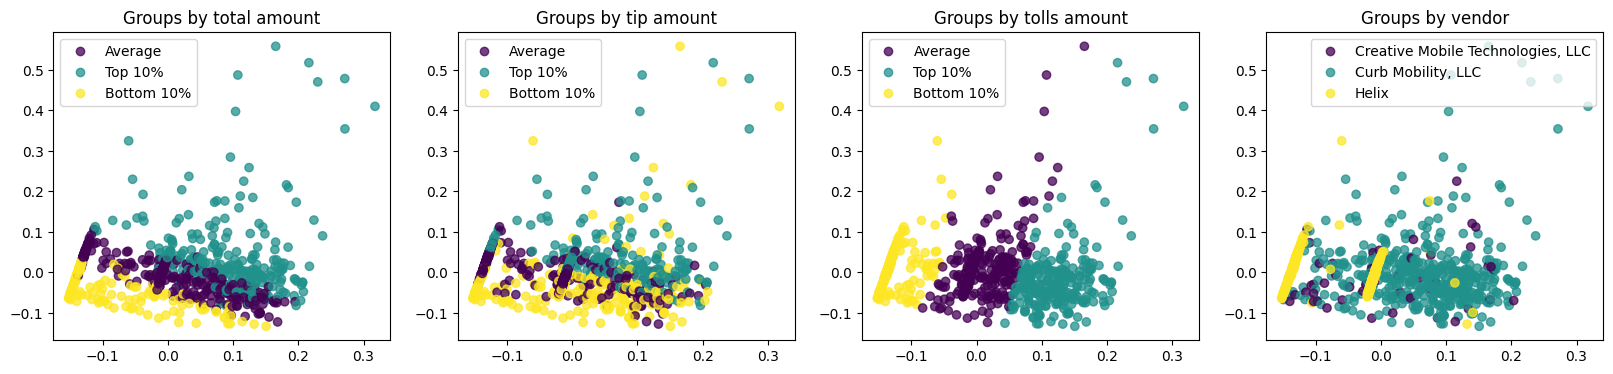

In [27]:
visualize_pca(data_range)

Data scatter:  5000.0
(1000, 1000)
[56.13 29.32 27.94 14.35  1.58]
[[ 0.494  0.083  0.35  -0.791 -0.014]
 [ 0.533  0.081  0.264  0.469 -0.648]
 [ 0.283 -0.816 -0.469 -0.114 -0.144]
 [ 0.292  0.565 -0.763 -0.094 -0.068]
 [ 0.554 -0.034  0.076  0.363  0.745]]
Contributions:  [3151.1   859.95  780.58  205.87    2.5 ]
Contributions (%):  [63.  17.2 15.6  4.1  0.1]


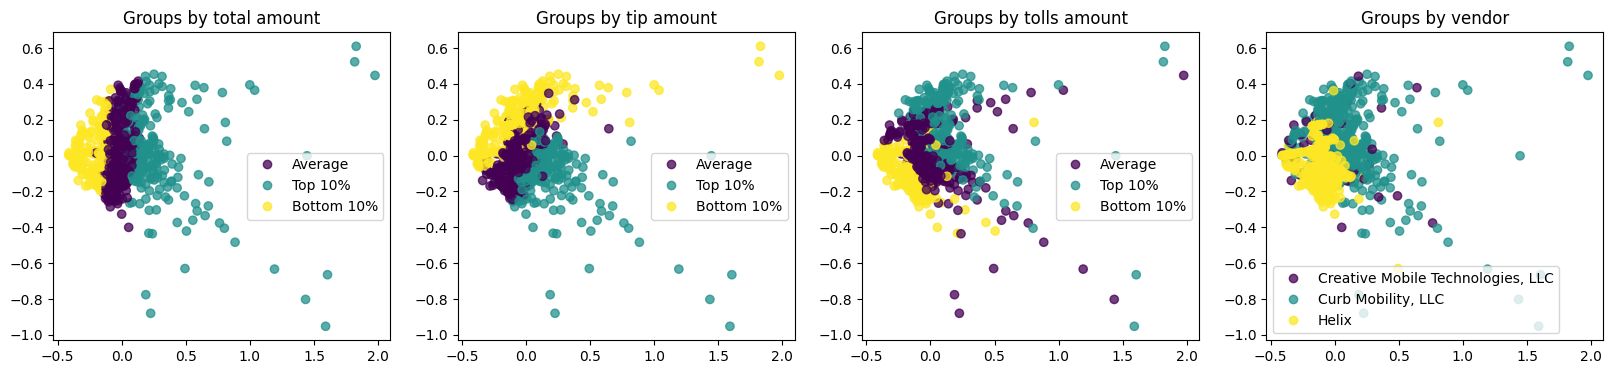

In [28]:
visualize_pca(data_zscore)

### Task 5
Also, apply the conventional PCA for finding two first principal components and visualization; compare to the results at z-scoring. Comment on which of the normalizations is better and why.

In [29]:
def PCA(data):
    def get_component(cov_matrix):
        eigvals, eigvecs = numpy.linalg.eig(cov_matrix)
        eigvecs = eigvecs[:, ~numpy.iscomplex(eigvals)]
        eigvals = eigvals[~numpy.iscomplex(eigvals)]
        
        eigval = eigvals[numpy.argmax(eigvals)]
        eigvec = eigvecs[:, numpy.argmax(eigvals)]
        pc = data @ eigvec / numpy.sqrt(len(data) * eigval)
        return eigval, eigvec, pc
    
    cov_matrix = data.T @ data / len(data)
    eigval, eigvec, pc1 = get_component(cov_matrix)
    cov_matrix = cov_matrix - eigval * (eigvec * eigvec.T)
    _, _, pc2 = get_component(cov_matrix)
    return pc1, pc2

d:\Programs\Programming\Python\lib\site-packages\matplotlib\cbook.py:1709: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
d:\Programs\Programming\Python\lib\site-packages\matplotlib\collections.py:200: ComplexWarning: Casting complex values to real discards the imaginary part
  offsets = np.asanyarray(offsets, float)


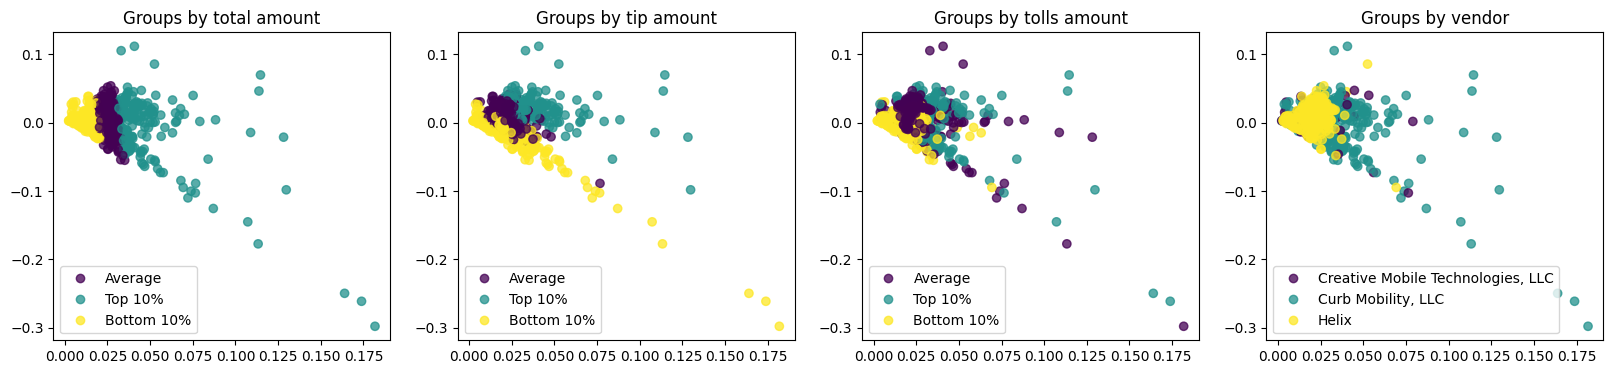

In [30]:
visualize(*PCA(data_npy))

### Task 6
Compute and interpret a hidden ranking factor behind the selected features. The factor should be expressed in a 0-100 rank scale (as well as the features – ranking normalization).

In [31]:
X = data_rank * 100
U, S, V = SVD(X)
vec = V[0] / V[0].sum()
print(vec)

data["ranking"] = X @ vec

Data scatter:  3306091.74
(1000, 1000)
[1717.03  496.27  305.09  135.37   14.42]
[[-0.264 -0.448 -0.412 -0.748 -0.014]
 [-0.238 -0.374 -0.302  0.487 -0.689]
 [-0.242 -0.449  0.845 -0.109 -0.121]
 [-0.85   0.524  0.028 -0.029 -0.025]
 [-0.305 -0.428 -0.156  0.436  0.714]]
Contributions:  [2948191.52  246286.     93080.54   18325.65     208.03]
Contributions (%):  [89.2  7.4  2.8  0.6  0. ]
[0.13892372 0.12515385 0.1274167  0.44798326 0.16052247]


C:\Users\TTPO100AJIEX\AppData\Local\Temp\ipykernel_10404\1572989334.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data["ranking"] = X @ vec


In [32]:
data.sort_values(by = 'ranking', ascending = False).head(10)

,trip_distance,fare_amount,tip_amount,tolls_amount,total_amount,ranking
492,68.61,455.9,0.00,18.66,484.06,81.999781
240,81.38,252.0,67.53,16.36,337.64,79.406640
482,57.87,319.4,30.00,17.38,372.03,74.934990
176,75.19,250.0,79.21,13.04,343.25,72.641550
419,85.19,431.5,0.00,13.30,452.55,70.345927
501,24.79,133.9,32.14,19.06,194.60,63.423960
317,88.35,486.0,0.00,8.69,497.44,62.884845
487,29.92,150.0,33.78,17.88,204.41,62.457659
450,33.93,162.6,45.37,14.88,228.60,59.020079
460,37.82,203.9,20.00,15.68,242.33,58.945404


In [33]:
data.sort_values(by = 'ranking', ascending = False).tail(10)

,trip_distance,fare_amount,tip_amount,tolls_amount,total_amount,ranking
805,0.00,9.3,3.51,0.0,21.06,1.215890
867,0.95,6.5,2.95,0.0,17.70,1.092769
506,0.79,5.8,2.66,0.0,15.96,0.945807
763,1.96,9.3,0.00,0.0,20.05,0.926309
521,2.05,10.0,0.00,0.0,16.50,0.841936
795,1.37,9.3,0.00,0.0,17.55,0.751457
4,0.00,3.0,0.00,0.2,8.95,0.561522
564,0.68,5.1,0.00,0.0,11.60,0.339453
829,0.00,4.4,0.00,0.0,12.65,0.248975
846,0.00,3.7,0.00,0.0,11.95,0.207966


Text(0, 0.5, 'Ranking factor')

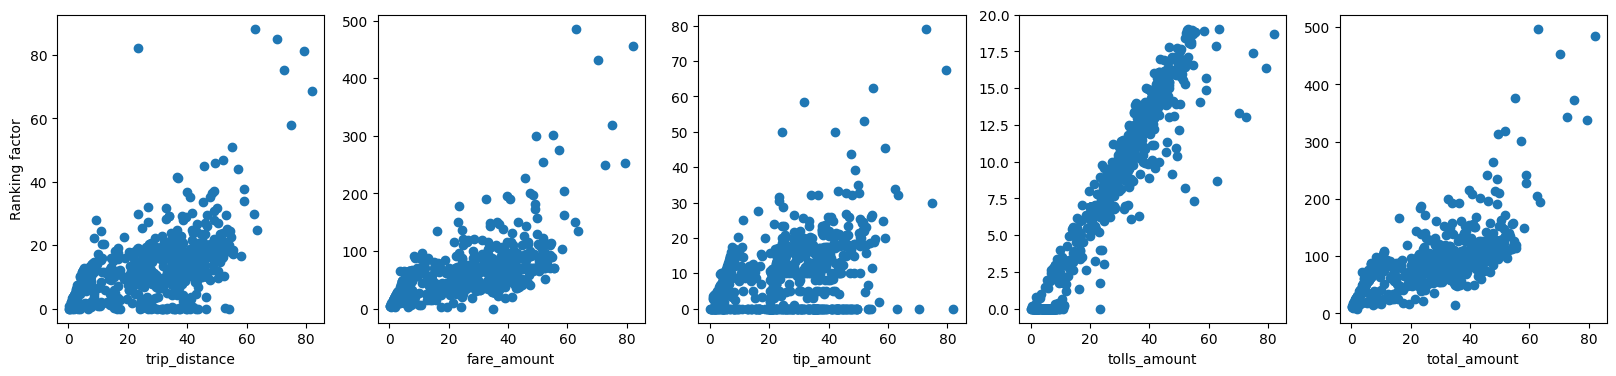

In [34]:
fig, axes = plt.subplots(1, 5, figsize = (20, 4))
for ax, feature in zip(axes, data.columns):
    ax.scatter(data["ranking"], data[feature])
    ax.set_xlabel(feature)
axes[0].set_ylabel("Ranking factor")

## Homework Assignment А3. Cluster analysis and cluster interpretation

In [35]:
data = full_data.drop(columns = [ "VendorID", "PULocationID", "DOLocationID", "payment_type" ])

data["Vendor1"] = (full_data["VendorID"] == 1).astype(int)
data["Vendor2"] = (full_data["VendorID"] == 2).astype(int)
data["Vendor7"] = (full_data["VendorID"] == 7).astype(int)

data["payment_type_1"] = (full_data["payment_type"] == 1).astype(int)
data["payment_type_2"] = (full_data["payment_type"] == 2).astype(int)
data["payment_type_3"] = (full_data["payment_type"] == 3).astype(int)
data["payment_type_4"] = (full_data["payment_type"] == 4).astype(int)

data

,passenger_count,trip_distance,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee,Vendor1,Vendor2,Vendor7,payment_type_1,payment_type_2,payment_type_3,payment_type_4
0,2.0,1.89,14.2,0.00,0.5,3.99,0.00,1.0,23.94,2.5,0.00,0.75,0,0,1,1,0,0,0
1,1.0,4.70,22.6,3.25,0.5,6.80,0.01,1.0,34.16,2.5,0.00,0.75,1,0,0,1,0,0,0
2,1.0,15.18,86.0,0.00,0.0,17.42,0.12,1.0,104.54,0.0,0.00,0.00,0,1,0,1,0,0,0
3,1.0,15.90,61.1,3.25,0.5,25.00,0.16,1.0,91.01,2.5,0.00,0.75,1,0,0,1,0,0,0
4,1.0,0.00,3.0,1.00,0.5,0.00,0.20,1.0,8.95,2.5,0.00,0.75,0,1,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,1.0,8.97,40.1,0.00,0.5,14.63,6.94,1.0,73.17,2.5,6.75,0.75,0,0,1,1,0,0,0
996,1.0,8.81,42.2,0.00,0.5,12.13,6.94,1.0,72.77,2.5,6.75,0.75,0,0,1,1,0,0,0
997,1.0,14.77,64.6,0.00,0.5,16.61,6.94,1.0,99.65,2.5,6.75,0.75,0,0,1,1,0,0,0
998,1.0,9.07,44.3,0.00,0.5,12.55,6.94,1.0,75.29,2.5,6.75,0.75,0,0,1,1,0,0,0


### Task 1

Choose 3 or more quantitative features, explain your choice and apply K-means clustering method:
- for K=4,
- for K=7.

At each of the two cases, make about 10 runs of the algorithm starting at random initializations, record information of them in the report, and choose the best of them according to the criterion value.

In [36]:
data_quant = full_data[["trip_distance", "fare_amount", "tip_amount", "tolls_amount", "total_amount"]]
data_quant = data_quant.to_numpy()

data_zscore = (data_quant - data_quant.mean(axis = 0)) / data_quant.std(axis = 0)
data_zscore.shape

(1000, 5)

In [37]:
import sklearn.cluster
random_states = [ 0, 1, 7, 10, 42, 750, 1234, 2025, 2026, 3058 ]

results = []
for random_state in random_states:
    scores = {'random_state': random_state}
    for k in [ 4, 7 ]:
        kmeans = sklearn.cluster.KMeans(n_clusters = k, random_state = random_state, init = 'random', n_init = 1)
        kmeans.fit(data_zscore)
        scores[k] = kmeans.inertia_
    results.append(scores)
results = pandas.DataFrame(results)
results

,random_state,4,7
0,0,2085.954793,1472.136965
1,1,2074.590548,1412.231376
2,7,2085.940490,1384.826590
3,10,2085.954793,1396.725426
4,42,2085.940490,1487.043989
5,750,2085.940490,1394.670713
6,1234,2091.540413,1439.088589
7,2025,2085.940490,1421.300674
8,2026,2091.608891,1423.735656
9,3058,2189.403776,1394.694353


In [38]:
results.sort_values(by = 4)

,random_state,4,7
1,1,2074.590548,1412.231376
2,7,2085.940490,1384.826590
4,42,2085.940490,1487.043989
5,750,2085.940490,1394.670713
7,2025,2085.940490,1421.300674
0,0,2085.954793,1472.136965
3,10,2085.954793,1396.725426
6,1234,2091.540413,1439.088589
8,2026,2091.608891,1423.735656
9,3058,2189.403776,1394.694353


In [39]:
results.sort_values(by = 7)

,random_state,4,7
2,7,2085.940490,1384.826590
5,750,2085.940490,1394.670713
9,3058,2189.403776,1394.694353
3,10,2085.954793,1396.725426
1,1,2074.590548,1412.231376
7,2025,2085.940490,1421.300674
8,2026,2091.608891,1423.735656
6,1234,2091.540413,1439.088589
0,0,2085.954793,1472.136965
4,42,2085.940490,1487.043989


In [40]:
kmeans4 = sklearn.cluster.KMeans(n_clusters = 4, random_state = 1, init = 'random', n_init = 1)
kmeans4.fit(data_zscore)
kmeans4.inertia_

2074.59054786315

In [41]:
kmeans7 = sklearn.cluster.KMeans(n_clusters = 7, random_state = 7, init = 'random', n_init = 1)
kmeans7.fit(data_zscore)
kmeans7.inertia_

1384.8265902547748

### Task 2

Interpret each of the two chosen partitions with the help of relative differences between within-cluster centers and the grand mean.

In [42]:
def analyze_kmeans(kmeans: sklearn.cluster.KMeans):
    def get_row(label, values):
        res = { feature: value for feature, value in zip(data.columns, values)}
        return { 'label': label, **res }

    data_npy = data.to_numpy()
    gmean = data_npy.mean(axis = 0)
    for cluster in range(kmeans.n_clusters):
        objs = data_npy[kmeans.labels_ == cluster]
        print(f"Cluster {cluster}: {len(objs)} objects")
        cmean = objs.mean(axis = 0)
        diff = cmean - gmean

        df = pandas.DataFrame([
            get_row('Grand mean', gmean),
            get_row('Cluster mean', cmean),
            get_row('Difference', diff),
            get_row('Rel. Diff.', 100 * diff / gmean)
        ])
        pandas.set_option('display.float_format', '{:.2f}'.format)
        display(df)
        pandas.reset_option('display.float_format')

In [43]:
analyze_kmeans(kmeans4)

Cluster 0: 13 objects


,label,passenger_count,trip_distance,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee,Vendor1,Vendor2,Vendor7,payment_type_1,payment_type_2,payment_type_3,payment_type_4
0,Grand mean,1.43,11.93,58.52,0.97,0.43,10.41,7.38,1.00,84.39,1.70,3.36,0.44,0.05,0.45,0.50,0.84,0.09,0.02,0.05
1,Cluster mean,1.54,62.06,302.55,2.35,0.12,25.98,11.32,1.00,345.43,0.00,1.87,0.17,0.00,0.92,0.08,0.69,0.31,0.00,0.00
2,Difference,0.11,50.13,244.03,1.38,-0.31,15.58,3.94,0.00,261.04,-1.70,-1.50,-0.27,-0.05,0.48,-0.43,-0.15,0.22,-0.02,-0.05
3,Rel. Diff.,7.43,420.17,417.03,142.94,-73.17,149.64,53.42,0.20,309.34,-100.00,-44.51,-61.02,-100.00,106.04,-84.68,-17.78,245.72,-100.00,-100.00


Cluster 1: 540 objects


,label,passenger_count,trip_distance,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee,Vendor1,Vendor2,Vendor7,payment_type_1,payment_type_2,payment_type_3,payment_type_4
0,Grand mean,1.43,11.93,58.52,0.97,0.43,10.41,7.38,1.00,84.39,1.70,3.36,0.44,0.05,0.45,0.50,0.84,0.09,0.02,0.05
1,Cluster mean,1.38,10.06,50.13,1.01,0.44,8.77,8.69,1.00,76.27,2.00,3.56,0.47,0.03,0.41,0.56,0.82,0.09,0.02,0.06
2,Difference,-0.05,-1.87,-8.38,0.05,0.01,-1.64,1.31,0.00,-8.11,0.30,0.20,0.02,-0.02,-0.04,0.06,-0.02,0.01,-0.00,0.02
3,Rel. Diff.,-3.53,-15.70,-14.32,4.98,2.50,-15.77,17.74,0.01,-9.62,17.92,5.84,4.79,-40.74,-8.65,11.78,-2.35,6.12,-7.41,33.96


Cluster 2: 252 objects


,label,passenger_count,trip_distance,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee,Vendor1,Vendor2,Vendor7,payment_type_1,payment_type_2,payment_type_3,payment_type_4
0,Grand mean,1.43,11.93,58.52,0.97,0.43,10.41,7.38,1.00,84.39,1.70,3.36,0.44,0.05,0.45,0.50,0.84,0.09,0.02,0.05
1,Cluster mean,1.38,8.05,39.10,0.39,0.49,7.48,0.71,1.00,56.12,1.48,4.69,0.44,0.08,0.17,0.76,0.83,0.10,0.04,0.02
2,Difference,-0.05,-3.88,-19.41,-0.58,0.06,-2.92,-6.67,-0.00,-28.27,-0.22,1.33,-0.00,0.03,-0.28,0.26,-0.01,0.01,0.02,-0.02
3,Rel. Diff.,-3.29,-32.50,-33.18,-59.94,14.43,-28.10,-90.40,-0.20,-33.49,-13.05,39.65,-0.12,50.79,-62.80,50.98,-1.03,15.93,80.38,-49.34


Cluster 3: 195 objects


,label,passenger_count,trip_distance,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee,Vendor1,Vendor2,Vendor7,payment_type_1,payment_type_2,payment_type_3,payment_type_4
0,Grand mean,1.43,11.93,58.52,0.97,0.43,10.41,7.38,1.00,84.39,1.70,3.36,0.44,0.05,0.45,0.50,0.84,0.09,0.02,0.05
1,Cluster mean,1.63,18.79,90.55,1.49,0.34,17.70,12.11,1.00,125.98,1.26,1.19,0.40,0.08,0.89,0.04,0.92,0.04,0.01,0.04
2,Difference,0.19,6.86,32.03,0.52,-0.09,7.29,4.73,0.00,41.59,-0.44,-2.17,-0.04,0.03,0.44,-0.47,0.08,-0.05,-0.02,-0.01
3,Rel. Diff.,13.52,57.46,54.74,54.12,-20.69,70.01,64.14,0.20,49.29,-26.09,-64.45,-9.04,53.85,98.03,-92.85,9.02,-53.90,-76.69,-23.62


In [44]:
analyze_kmeans(kmeans7)

Cluster 0: 106 objects


,label,passenger_count,trip_distance,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee,Vendor1,Vendor2,Vendor7,payment_type_1,payment_type_2,payment_type_3,payment_type_4
0,Grand mean,1.43,11.93,58.52,0.97,0.43,10.41,7.38,1.00,84.39,1.70,3.36,0.44,0.05,0.45,0.50,0.84,0.09,0.02,0.05
1,Cluster mean,1.46,4.41,23.13,0.70,0.50,1.87,3.01,0.99,35.25,1.44,3.30,0.34,0.15,0.31,0.54,0.52,0.31,0.11,0.06
2,Difference,0.03,-7.52,-35.38,-0.27,0.07,-8.54,-4.37,-0.01,-49.14,-0.26,-0.06,-0.10,0.10,-0.14,0.04,-0.32,0.22,0.09,0.01
3,Rel. Diff.,2.11,-63.03,-60.47,-27.96,15.18,-82.08,-59.16,-0.74,-58.23,-15.37,-1.70,-23.51,201.89,-30.51,7.12,-38.38,249.80,414.58,20.43


Cluster 1: 27 objects


,label,passenger_count,trip_distance,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee,Vendor1,Vendor2,Vendor7,payment_type_1,payment_type_2,payment_type_3,payment_type_4
0,Grand mean,1.43,11.93,58.52,0.97,0.43,10.41,7.38,1.00,84.39,1.70,3.36,0.44,0.05,0.45,0.50,0.84,0.09,0.02,0.05
1,Cluster mean,1.41,35.61,173.36,2.10,0.28,16.62,10.42,1.00,205.78,0.37,1.68,0.11,0.11,0.85,0.04,0.78,0.19,0.00,0.04
2,Difference,-0.02,23.68,114.84,1.14,-0.15,6.21,3.04,0.00,121.39,-1.33,-1.69,-0.33,0.06,0.40,-0.46,-0.06,0.10,-0.02,-0.01
3,Rel. Diff.,-1.72,198.44,196.26,117.64,-35.40,59.65,41.22,0.20,143.85,-78.21,-50.14,-74.97,122.22,90.15,-92.62,-7.63,108.07,-100.00,-21.20


Cluster 2: 162 objects


...

,label,passenger_count,trip_distance,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee,Vendor1,Vendor2,Vendor7,payment_type_1,payment_type_2,payment_type_3,payment_type_4
0,Grand mean,1.43,11.93,58.52,0.97,0.43,10.41,7.38,1.00,84.39,1.70,3.36,0.44,0.05,0.45,0.50,0.84,0.09,0.02,0.05
1,Cluster mean,1.64,14.98,79.05,1.43,0.34,19.66,11.93,1.00,116.25,1.35,1.08,0.43,0.07,0.89,0.04,1.00,0.00,0.00,0.00
2,Difference,0.21,3.05,20.54,0.47,-0.09,9.25,4.54,0.00,31.87,-0.35,-2.28,-0.01,0.02,0.45,-0.46,0.16,-0.09,-0.02,-0.05
3,Rel. Diff.,14.46,25.57,35.10,48.58,-20.19,88.89,61.58,0.20,37.76,-20.81,-67.92,-3.05,30.18,99.44,-91.75,18.76,-100.00,-100.00,-100.00


Cluster 5: 175 objects


,label,passenger_count,trip_distance,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee,Vendor1,Vendor2,Vendor7,payment_type_1,payment_type_2,payment_type_3,payment_type_4
0,Grand mean,1.43,11.93,58.52,0.97,0.43,10.41,7.38,1.00,84.39,1.70,3.36,0.44,0.05,0.45,0.50,0.84,0.09,0.02,0.05
1,Cluster mean,1.34,10.37,48.88,0.21,0.49,9.89,0.34,1.00,68.74,1.63,5.31,0.49,0.03,0.11,0.86,0.95,0.03,0.00,0.01
2,Difference,-0.09,-1.56,-9.63,-0.76,0.06,-0.52,-7.04,0.00,-15.65,-0.07,1.94,0.05,-0.02,-0.33,0.36,0.11,-0.05,-0.02,-0.04
3,Rel. Diff.,-6.23,-13.07,-16.46,-78.40,12.96,-5.00,-95.40,0.20,-18.55,-4.20,57.84,11.00,-42.86,-74.49,70.75,13.34,-61.48,-100.00,-75.68


Cluster 6: 8 objects


,label,passenger_count,trip_distance,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee,Vendor1,Vendor2,Vendor7,payment_type_1,payment_type_2,payment_type_3,payment_type_4
0,Grand mean,1.43,11.93,58.52,0.97,0.43,10.41,7.38,1.00,84.39,1.70,3.36,0.44,0.05,0.45,0.50,0.84,0.09,0.02,0.05
1,Cluster mean,1.75,69.30,343.88,2.00,0.06,36.51,12.86,1.00,397.81,0.00,1.31,0.19,0.00,1.00,0.00,0.75,0.25,0.00,0.00
2,Difference,0.32,57.37,285.36,1.03,-0.37,26.10,5.48,0.00,313.42,-1.70,-2.05,-0.26,-0.05,0.55,-0.50,-0.09,0.16,-0.02,-0.05
3,Rel. Diff.,22.21,480.79,487.66,107.09,-85.47,250.77,74.29,0.20,371.41,-100.00,-60.95,-57.77,-100.00,123.21,-100.00,-10.93,180.90,-100.00,-100.00


## Assignment A4: Contingency Table

### Task 1.

Consider two nominal features over your dataset (one of them, not more, may be taken from nominal features in your data, the other is to be developed by yourself). 

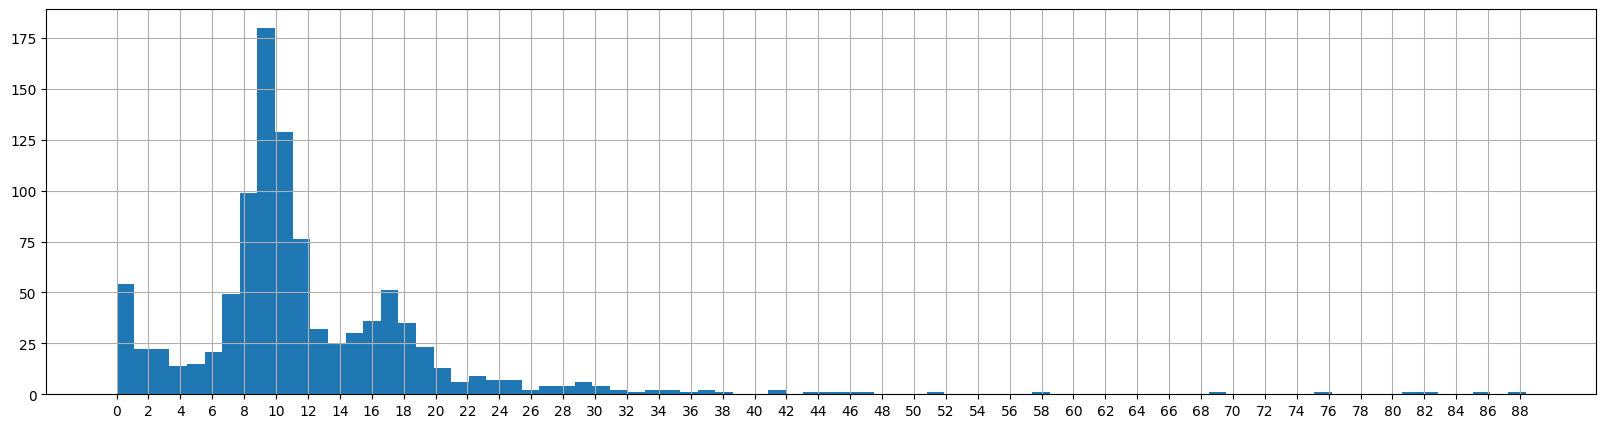

In [45]:
full_data["trip_distance"].hist(bins = 80, figsize = (20, 5))
plt.xticks(range(0, 90, 2))
None

In [46]:
passenger_count = full_data["passenger_count"].to_numpy().astype(int)
trip_distance = (
    1 * ((full_data["trip_distance"] >= 0) & (full_data["trip_distance"] < 4)).astype(int) +
    2 * ((full_data["trip_distance"] >= 4) & (full_data["trip_distance"] < 14)).astype(int) +
    3 * ((full_data["trip_distance"] >= 14) & (full_data["trip_distance"] < 22)).astype(int) +
    4 * (full_data["trip_distance"] >= 22).astype(int)
).to_numpy()

numpy.unique(passenger_count, return_counts = True), numpy.unique(trip_distance, return_counts = True)

((array([0, 1, 2, 3, 4]), array([  1, 721, 169,  63,  46], dtype=int64)),
 (array([1, 2, 3, 4]), array([106, 624, 202,  68], dtype=int64)))

### Task 2.

Build a contingency table over them; compute conditional frequency and Quetelet index tables. Make comments on maximally associated categories of the features.

In [47]:
def draw_table(table: numpy.ndarray) -> pandas.DataFrame:
    return pandas.DataFrame(table, columns = ['[0, 4)', '[4, 14)', '[14, 22)', '[22, +inf)'])

passenger_count_values = list(sorted(numpy.unique(passenger_count)))
trip_distance_values = list(sorted(numpy.unique(trip_distance)))

passenger_count_values, trip_distance_values

([0, 1, 2, 3, 4], [1, 2, 3, 4])

In [48]:
contingency_table = pandas.crosstab(passenger_count, trip_distance).to_numpy()
assert contingency_table.sum() == len(full_data)
display(draw_table(contingency_table))
contingency_table.sum(axis = 0), contingency_table.sum(axis = 1)

,"[0, 4)","[4, 14)","[14, 22)","[22, +inf)"
0,0,0,1,0
1,64,478,131,48
2,16,105,39,9
3,12,26,19,6
4,14,15,12,5


(array([106, 624, 202,  68], dtype=int64),
 array([  1, 721, 169,  63,  46], dtype=int64))

In [49]:
relative_frequency = contingency_table / contingency_table.sum()
assert numpy.allclose(relative_frequency.sum(), 1)
draw_table(relative_frequency)

,"[0, 4)","[4, 14)","[14, 22)","[22, +inf)"
0,0.000,0.000,0.001,0.000
1,0.064,0.478,0.131,0.048
2,0.016,0.105,0.039,0.009
3,0.012,0.026,0.019,0.006
4,0.014,0.015,0.012,0.005


In [50]:
conditional_frequency = relative_frequency / relative_frequency.sum(axis = 0)
assert numpy.allclose(conditional_frequency.sum(axis = 0), 1.0)
draw_table(conditional_frequency)

,"[0, 4)","[4, 14)","[14, 22)","[22, +inf)"
0,0.000000,0.000000,0.004950,0.000000
1,0.603774,0.766026,0.648515,0.705882
2,0.150943,0.168269,0.193069,0.132353
3,0.113208,0.041667,0.094059,0.088235
4,0.132075,0.024038,0.059406,0.073529


In [51]:
quetlet_index = conditional_frequency / relative_frequency.sum(axis = 1).reshape(-1, 1) - 1
draw_table(quetlet_index)

,"[0, 4)","[4, 14)","[14, 22)","[22, +inf)"
0,-1.000000,-1.000000,3.950495,-1.000000
1,-0.162589,0.062449,-0.100534,-0.020968
2,-0.106844,-0.004324,0.142422,-0.216847
3,0.796945,-0.338624,0.493006,0.400560
4,1.871206,-0.477425,0.291433,0.598465


### Task 3.

Compute and compare the average Quetelet index and Pearson’s chi-squared.

In [52]:
print("Average Quetelet: ", (relative_frequency * quetlet_index).sum())

Average Quetelet:  0.04871290328358221


In [53]:
expected = numpy.outer(relative_frequency.sum(axis = 1), relative_frequency.sum(axis = 0))
chi2 = ((relative_frequency - expected) ** 2 / expected).sum()
print("Chi-squared: ", chi2)

Chi-squared:  0.04871290328358242


### Task 4.

Tell what numbers of observations would suffice to see the features as associated at 95% confidence level; 99% confidence level – consult internet for statistical tables if needed. 

In [54]:
import scipy.stats
df = (len(passenger_count_values) - 1) * (len(trip_distance_values) - 1)
print("At 95%: ", scipy.stats.chi2.ppf(0.95, df) / chi2)
print("At 99%: ", scipy.stats.chi2.ppf(0.99, df) / chi2)

At 95%:  431.63245054559144
At 99%:  538.1934875224669


##  HomeWork A5: Bootstrap

Note: each application of bootstrap should be done in both versions, pivotal and non-pivotal.

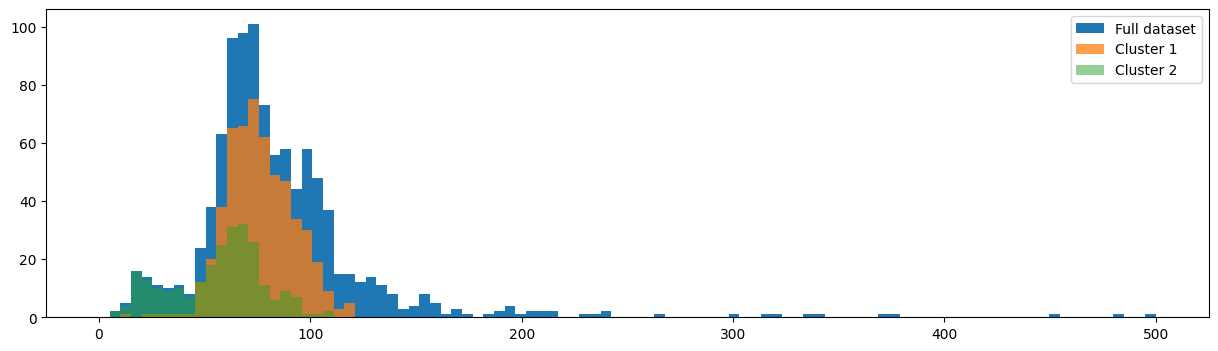

In [55]:
feature = data_quant[:, 4] # total_amount
cluster1 = feature[kmeans4.labels_ == 1]
cluster2 = feature[kmeans4.labels_ == 2]

plt.figure(figsize = (15, 4))
bins = numpy.linspace(0, 500, 100)
plt.hist(feature, bins = bins, label = 'Full dataset')
plt.hist(cluster1, bins = bins, label = 'Cluster 1', alpha = 0.75)
plt.hist(cluster2, bins = bins, label = 'Cluster 2', alpha = 0.5)
plt.legend()
None

In [56]:
def print_confidence_gaussian(data: numpy.ndarray, alpha: float = 0.95):
    betta = (1 - alpha) / 2
    norm_ppf = scipy.stats.norm.ppf(1 - betta)

    data_mean, data_std = data.mean(), data.std()
    gaussian_min = data_mean - norm_ppf * data_std
    gaussian_max = data_mean + norm_ppf * data_std
    print(f"Mean under Gaussian assumption: {data_mean:.2f} ∈ [{gaussian_min:.2f}; {gaussian_max:.2f}]")
    
def print_confidence_bootstrap(data: numpy.ndarray, alpha: float = 0.95):
    betta = (1 - alpha) / 2
    norm_ppf = scipy.stats.norm.ppf(1 - betta)

    plt.figure(figsize = (5, 2))
    plt.title("Bootstrap means")
    plt.hist(data)
    
    bootstrap_mean, bootstrap_std = data.mean(), data.std()
    pivotal_min = bootstrap_mean - norm_ppf * bootstrap_std
    pivotal_max = bootstrap_mean + norm_ppf * bootstrap_std
    print(f"Bootstrap pivotal: {data.mean():.2f} ∈ [{pivotal_min:.2f}; {pivotal_max:.2f}]")
    
    non_pivotal_min = numpy.percentile(data, 100 * betta)
    non_pivotal_max = numpy.percentile(data, 100 * (1 - betta))
    print(f"Bootstrap non-pivotal: {data.mean():.2f} ∈ [{non_pivotal_min:.2f}; {non_pivotal_max:.2f}]")

### Task 1

Find the 95% confidence interval for its grand mean by using bootstrap 

Mean under Gaussian assumption: 84.39 ∈ [-3.28; 172.05]
Bootstrap pivotal: 84.37 ∈ [81.61; 87.14]
Bootstrap non-pivotal: 84.37 ∈ [81.69; 87.25]


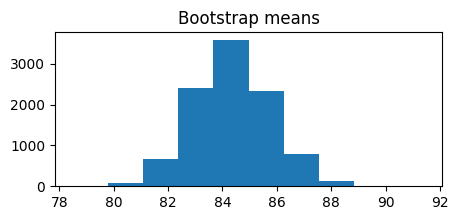

In [57]:
def estimate_mean(data: numpy.ndarray, alpha: float = 0.95, bootstrap_iter: int = 10000, random_state: int = 42):
    numpy.random.seed(random_state)
    samples = numpy.random.choice(data, size = (len(data), bootstrap_iter), replace = True)
    print_confidence_gaussian(data, alpha)
    print_confidence_bootstrap(samples.mean(axis = 0), alpha)

estimate_mean(feature)

### Task 2

Compare means of the feature in two clusters using bootstrap

Bootstrap pivotal: 20.18 ∈ [17.19; 23.18]
Bootstrap non-pivotal: 20.18 ∈ [17.18; 23.15]


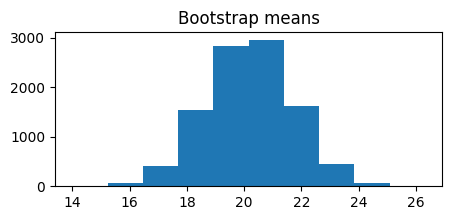

In [58]:
def compare_means(data1: numpy.ndarray, data2: numpy.ndarray, bootstrap_iter: int = 10000, random_state: int = 42):
    numpy.random.seed(random_state)

    samples1 = numpy.random.choice(data1, size = (len(data1), bootstrap_iter), replace = True)
    means1: numpy.ndarray = samples1.mean(axis = 0)
    
    samples2 = numpy.random.choice(data2, size = (len(data2), bootstrap_iter), replace = True)
    means2: numpy.ndarray = samples2.mean(axis = 0)

    print_confidence_bootstrap(means1 - means2)
    
compare_means(cluster1, cluster2)

### Task 3

Take that cluster in which the within-cluster mean is the nearest to the grand mean and test the hypothesis that these two means coincide by using bootstrap

Mean under Gaussian assumption: 76.27 ∈ [45.67; 106.87]
Bootstrap pivotal: 76.27 ∈ [74.95; 77.59]
Bootstrap non-pivotal: 76.27 ∈ [74.93; 77.57]


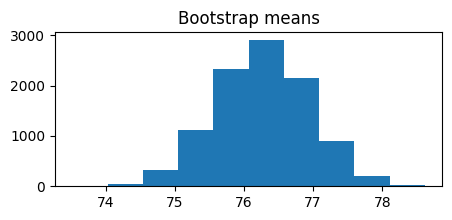

In [59]:
estimate_mean(cluster1)

Mean under Gaussian assumption: 56.12 ∈ [13.26; 98.98]
Bootstrap pivotal: 56.12 ∈ [53.42; 58.81]
Bootstrap non-pivotal: 56.12 ∈ [53.41; 58.82]


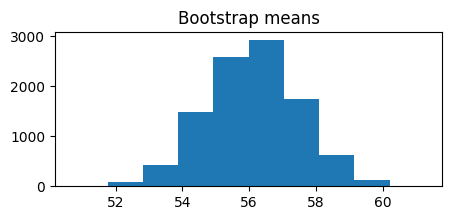

In [60]:
estimate_mean(cluster2)

Cluster 1 is closer to the grand mean

Bootstrap pivotal: 8.10 ∈ [5.05; 11.15]
Bootstrap non-pivotal: 8.10 ∈ [5.13; 11.26]


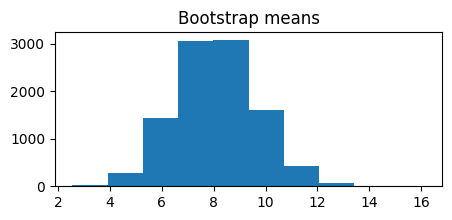

In [61]:
compare_means(feature, cluster1)